## 4.1 Fourier Optics Examples in python

###  Example 1 : difference between Fast Fourier Transform (FFT) and Discrete Fourier Transform (DFT)

#### DFT vs FFT: A Practical Comparison

This notebook compares the **Discrete Fourier Transform (DFT)** and the **Fast Fourier Transform (FFT)**.  
Both produce identical numerical results, but their computational efficiency differs dramatically.

##### Theory

For a sequence $g[n]$ of length $N$, the DFT is defined as  

$$
G[k] = \sum_{n=0}^{N-1} g[n] \, e^{-i 2\pi k n / N}, \qquad k = 0,\dots,N-1
$$

A direct implementation uses two nested loops, requiring $O(N^2)$ operations.  
The FFT is a family of algorithms that compute the **same** DFT in $O(N \log N)$ operations by exploiting symmetries and periodicities of the complex exponentials.

For large $N$ (e.g., $N=1064$), the difference in speed is enormous – the FFT completes in milliseconds, while a manual DFT may take minutes or hours.

##### What this code does

1. **Creates a shifted input signal**  
   The original Gaussian $g(x) = \exp[-(x/w_0)^2]$ (with $w_0 = 0.2$) is circularly shifted by $N/2$ using two manual loops. This shift is kept for illustration; the comparison works for any input.

2. **Implements a manual DFT** (double loop) – intentionally slow, for educational purposes.

3. **Computes the FFT** using `np.fft.fft` – fast, production‑ready.

4. **Compares execution times** with Python’s `time` module, showing the huge speed advantage of the FFT.

5. **Verifies numerical equivalence** – the two outputs match up to floating‑point precision.

6. **Plots magnitude and phase** of both transforms, confirming they are identical.

##### Why this is helpful

- **Understanding the cost of a naive DFT** – you will see that an $O(N^2)$ algorithm becomes unusable for realistic data sizes.
- **Appreciating why libraries use FFT** – in Fourier optics, images are often $1024 \times 1024$ or larger; an FFT is essential.
- **Recognising that the FFT is not an approximation** – it is an exact re‑implementation of the DFT.
- **Learning to use timing as a tool** for comparing algorithm performance.

For any real Fourier optics simulation, always use `numpy.fft` (or `scipy.fft`). The manual DFT shown here is purely for illustration.

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import time


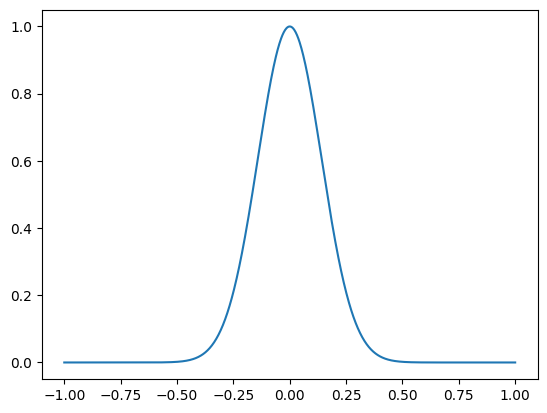

In [29]:
N = 1024
x0 = np.linspace(-1, 1, N)
delta = x0[1] - x0[0]
w0 = 2e-1
gx = lambda x : np.exp(-(x / w0)**2)
gx = gx(x0)
plt.plot(x0, gx)


In [30]:
np2 = [x for x in range(0, int(N))]

In [31]:
gxp = []

for i in range(0, int(N/2)):
    # print(int((i + N/2)))
    gxp.append(gx[int((i + N/2))])

for i in range(0, int(N/2)):
    # print(int((i)))
    gxp.append(gx[int(i)])


In [32]:
len(gxp) == len(gx) == N

True

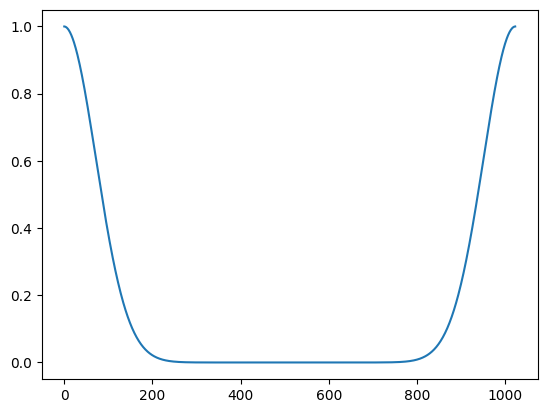

In [33]:
plt.plot(np2, gxp)

In [34]:
Gm = np.zeros(N, dtype=complex)
start_t = time.time()
for k in range(N):                  
    s = 0 + 0j
    for n in range(N):              
        s += gxp[n] * np.exp(-2j * np.pi * k * n / N)
    Gm[k] = s

end_t = time.time()
time_manual = end_t - start_t
print(f"Manual DFT completed in {time_manual:.2f} seconds")

Manual DFT completed in 2.09 seconds


Starting NumPy FFT...
NumPy FFT completed in 0.000000 seconds
Time difference between manual DFT and FFT: 2.0054731369018555 seconds
Max difference between manual DFT and FFT: 5.47e-11


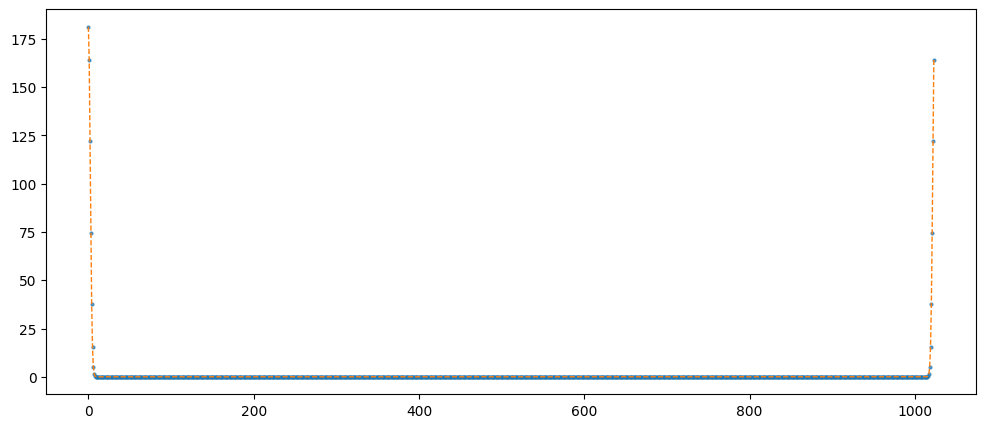

C:\Users\MOBIT\AppData\Local\Temp\ipykernel_21344\3007832109.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


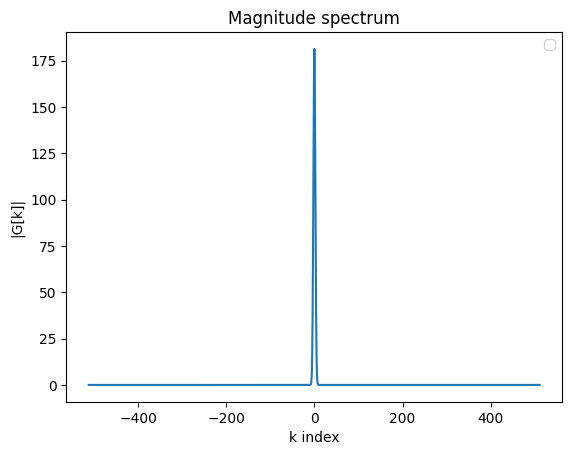

In [73]:
# -------------------  FFT  -------------------

print("Starting NumPy FFT...")
start_fft = time.time()
G_fft = np.fft.fft(gxp)          # FFT of the same shifted signal


end_fft = time.time()
time_fft = end_fft - start_fft
print(f"NumPy FFT completed in {time_fft:.6f} seconds")

# difference of the times
print(f"Time difference between manual DFT and FFT: {time_manual - time_fft} seconds")

# difference of the values
diff = np.max(np.abs(Gm - G_fft))
print(f"Max difference between manual DFT and FFT: {diff:.2e}")

# ------------------- Plot comparison -------------------
plt.figure(3, figsize=(12, 5))

plt.plot(np.abs(Gm), 'o', label='Manual DFT', markersize=2, alpha=0.7)
plt.plot(np.abs(G_fft), '--', label='NumPy FFT', linewidth=1)
plt.show()
plt.title('Magnitude spectrum')
plt.xlabel('k index')
plt.ylabel('|G[k]|')
plt.legend()
Gm_shifted = np.concatenate((Gm[N//2:], Gm[:N//2]))
k_shifted = np.arange(-N//2, N//2)
plt.plot(k_shifted, np.abs(Gm_shifted))
plt.show()


In [36]:
# <!-- Starting NumPy FFT...
# NumPy FFT completed in 0.000000 seconds
# Time difference between manual DFT and FFT: 1.4666252136230469
# Max difference between manual DFT and FFT: 4.67e-11 -->
# -------------------------------------------------------
# Starting NumPy FFT...
# NumPy FFT completed in 0.002990 seconds
# Time difference between manual DFT and FFT: 88.73701930046082 seconds
# Max difference between manual DFT and FFT: 1.98e-09

###  FFT -- Examples

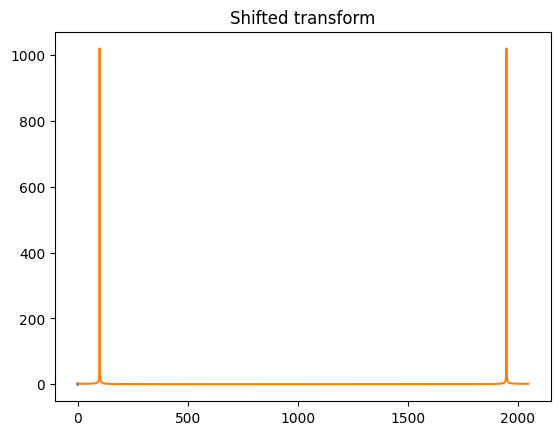

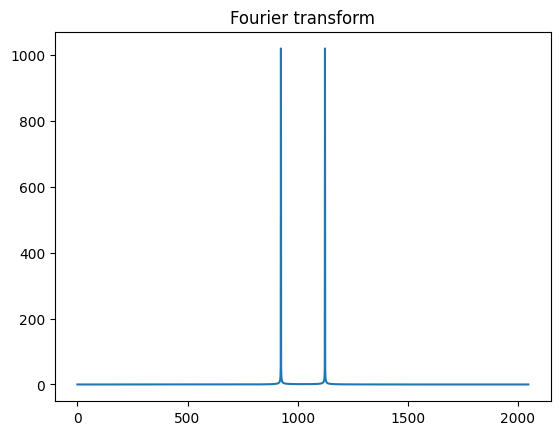

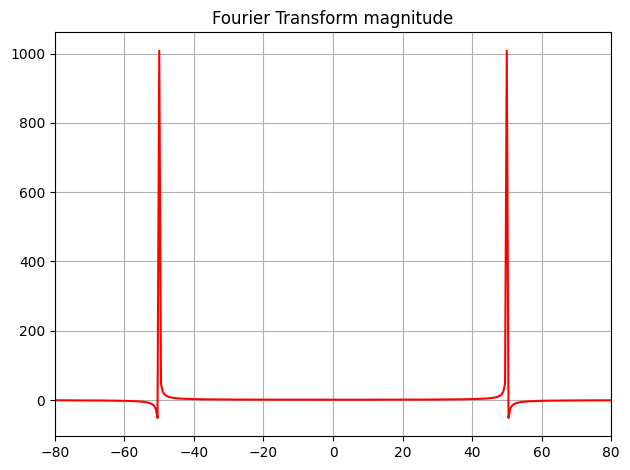

In [37]:
N = 2048
x_min, x_max = -1, 1
x = np.linspace(-1, 1, N)
dx = x[1] - x[0] # delta 
f = 50
s = np.cos(2*np.pi*f*x) # function
plt.plot(x, s)
S = np.fft.fft(s) # Fourier transform
plt.plot(np.abs(S))
plt.title("Shifted transform")
plt.show()

S = np.fft.fftshift(S) # Fourier transform shift
plt.plot(np.abs(S))
plt.title("Fourier transform")
plt.show()


freq = np.fft.fftfreq(N, d=dx)        # Fourier transform in frequency domain
freq_centered = np.fft.fftshift(freq)  # Shift fourier frequency

# Plotting


# Frequency domain (magnitude)
plt.plot(freq_centered, S, 'r-')
plt.title('Fourier Transform magnitude')
plt.grid(True)
plt.xlim(-80, 80)

plt.tight_layout()
plt.show()

### A wave with two Sin functions

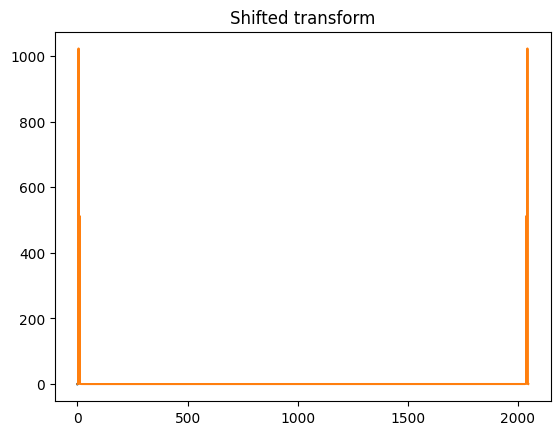

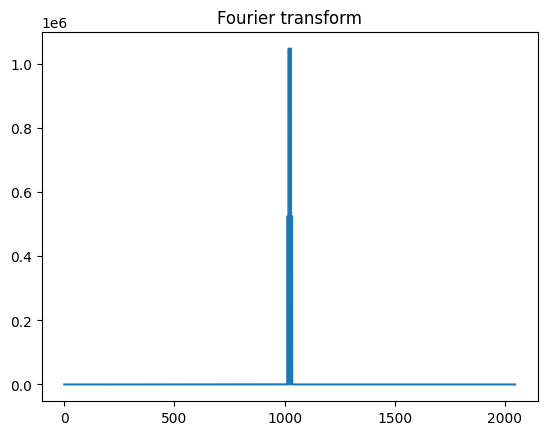

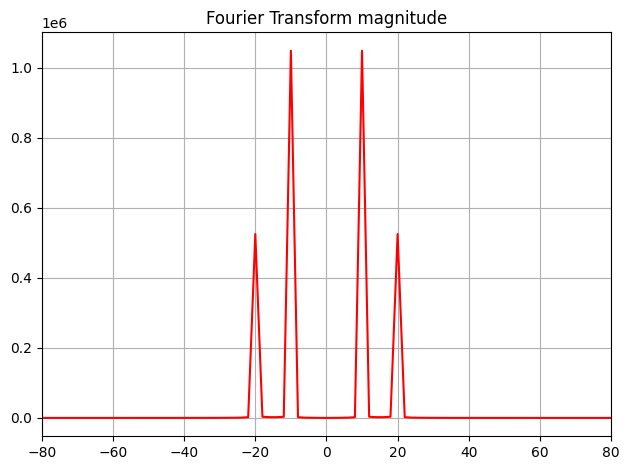

In [52]:
N = 2048
x_min, x_max = -0.25, 0.25
x = np.linspace(x_min,x_max, N)
dx = x[1] - x[0] # delta 
f1 = 10
f2 = 20
a1 = 1
a2 = 0.5

s = a1*np.sin(2*np.pi*f1*x) + a2*np.sin(2*np.pi*f2*x) # function

plt.plot(x, s)
S = np.fft.fft(s) # Fourier transform
plt.plot(np.abs(S))
plt.title("Shifted transform")
plt.show()

S = np.fft.fftshift(S) *N/2# Fourier transform shift
plt.plot(np.abs(S))
plt.title("Fourier transform")
plt.show()


freq = np.fft.fftfreq(N, d=dx)        # Fourier transform in frequency domain
freq_centered = np.fft.fftshift(freq)  # Shift fourier frequency

# Plotting


# Frequency domain (magnitude)
plt.plot(freq_centered, np.abs(S), 'r-')
plt.title('Fourier Transform magnitude')
plt.grid(True)
plt.xlim(-80, 80)

plt.tight_layout()
plt.show()

### A noisy wave example

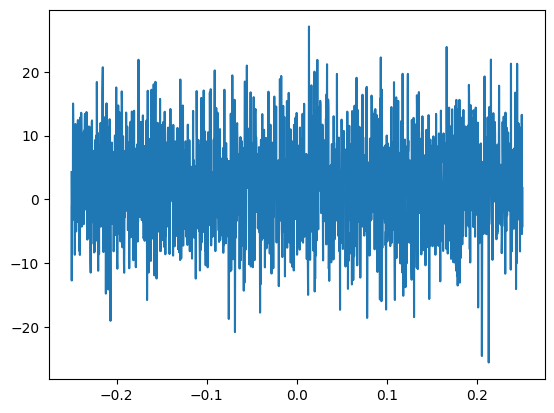

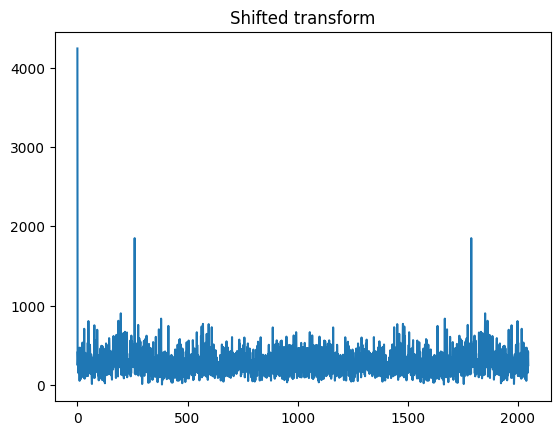

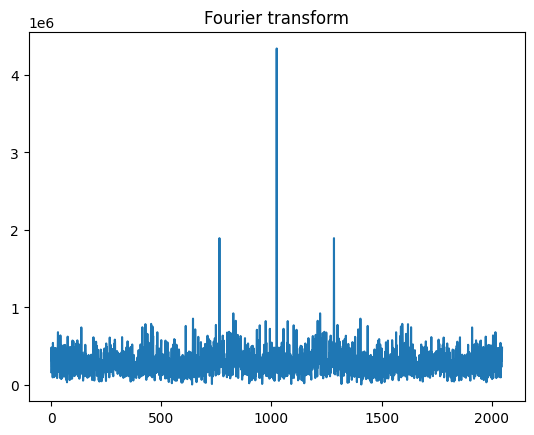

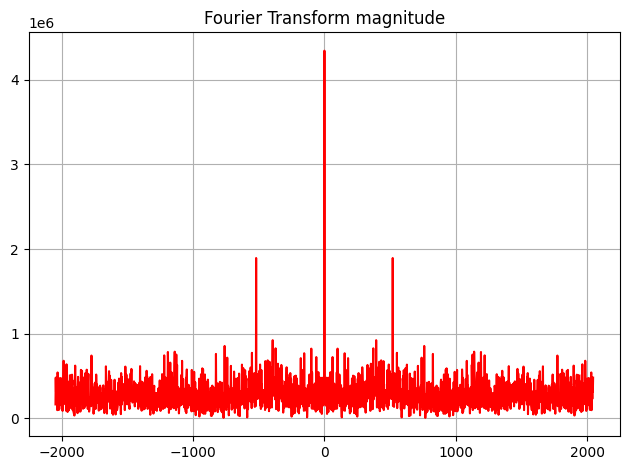

In [68]:
N = 2048
x_min, x_max = -0.25, 0.25
x = np.linspace(x_min,x_max, N)
dx = x[1] - x[0] # delta 
f1 = 1050
f2 = 520
f3 = 851
a1 = 0.5
a2 = 1.5
a3 = 0.3

s = a1*np.cos(2*np.pi*f1*x) + a2*np.cos(2*np.pi*f2*x) + a3*np.cos(2*np.pi*f3*x) + 2 # function
noise = np.random.randn(len(x)) * 7   
s = s + noise
plt.plot(x, s)
plt.show()

S = np.fft.fft(s) # Fourier transform
plt.plot(np.abs(S))
plt.title("Shifted transform")
plt.show()

S = np.fft.fftshift(S) *N/2# Fourier transform shift
plt.plot(np.abs(S))
plt.title("Fourier transform")
plt.show()


freq = np.fft.fftfreq(N, d=dx)        # Fourier transform in frequency domain
freq_centered = np.fft.fftshift(freq)  # Shift fourier frequency

# Plotting


# Frequency domain (magnitude)
plt.plot(freq_centered, np.abs(S), 'r-')
plt.title('Fourier Transform magnitude')
plt.grid(True)


plt.tight_layout()
plt.show()